# Argo Float Census — California Domain (2001–2025)

Visual browser for the float density maps generated by `09_ae_longterm_float_census.py` and `09b_ae_analyze_float_census.py`.

**Output directory:** `AEResults/aeplots/float_census_california/`

**Purpose:** Review float coverage to inform `californiav3` domain definition.

In [2]:
import os
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets

# Resolve census directory relative to this notebook's location
NOTEBOOK_DIR = Path(os.path.abspath(''))
CENSUS_DIR = NOTEBOOK_DIR / 'AEResults' / 'aeplots' / 'float_census_california'

# Collect per-year PNGs in chronological order
year_pngs = sorted(CENSUS_DIR.glob('float_census_california_20??.png'))
years = [int(p.stem.split('_')[-1]) for p in year_pngs]

print(f'Found {len(years)} per-year maps: {years[0]}–{years[-1]}')

Found 25 per-year maps: 2001–2025


## Summary Plots

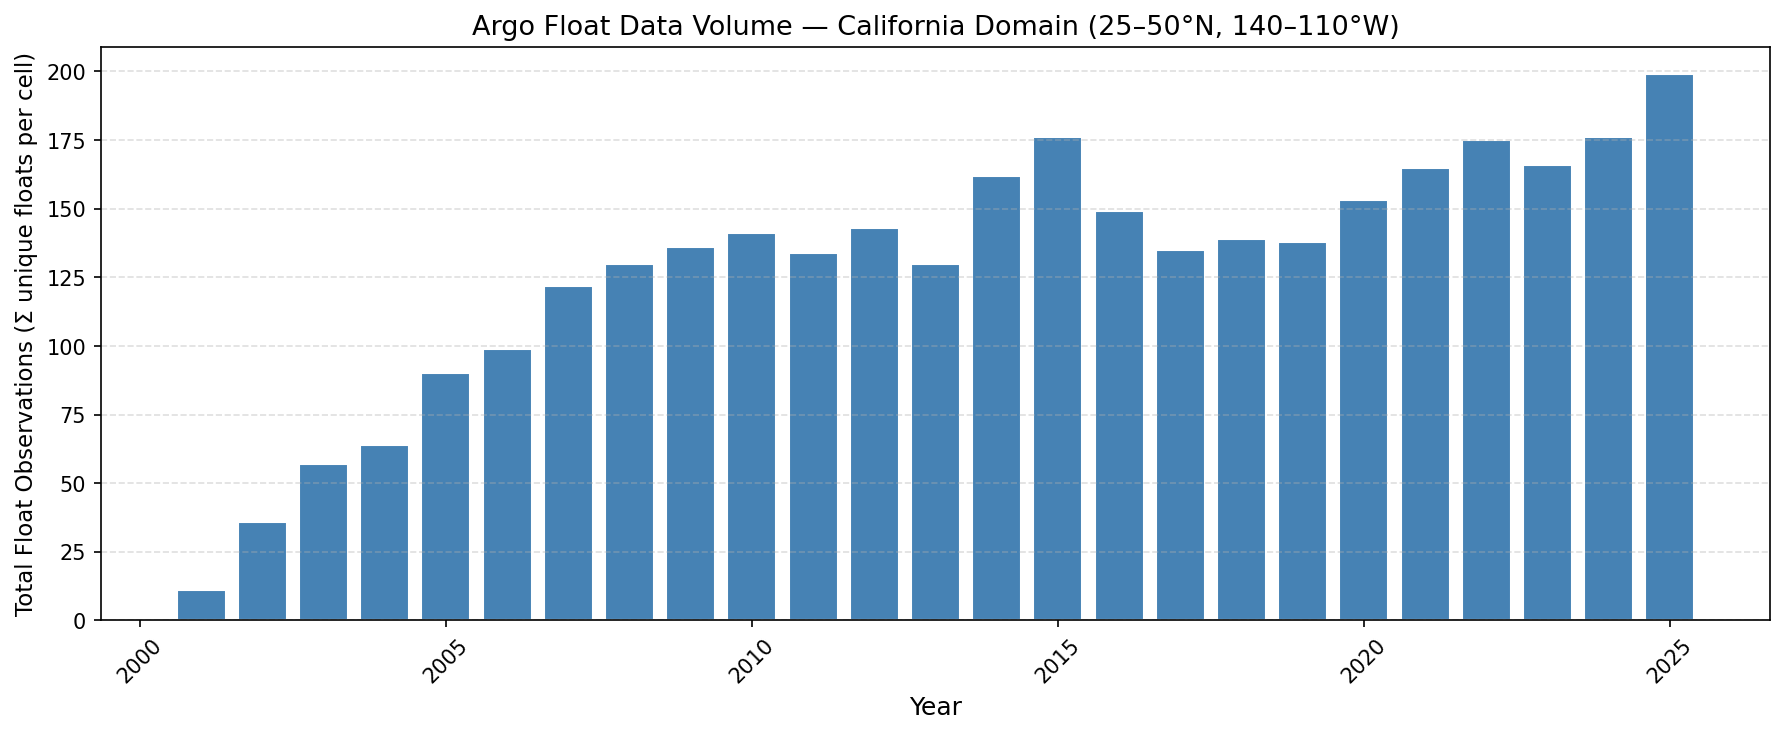

In [3]:
# Annual float totals bar chart
display(Image(filename=str(CENSUS_DIR / 'float_census_annual_totals.png')))

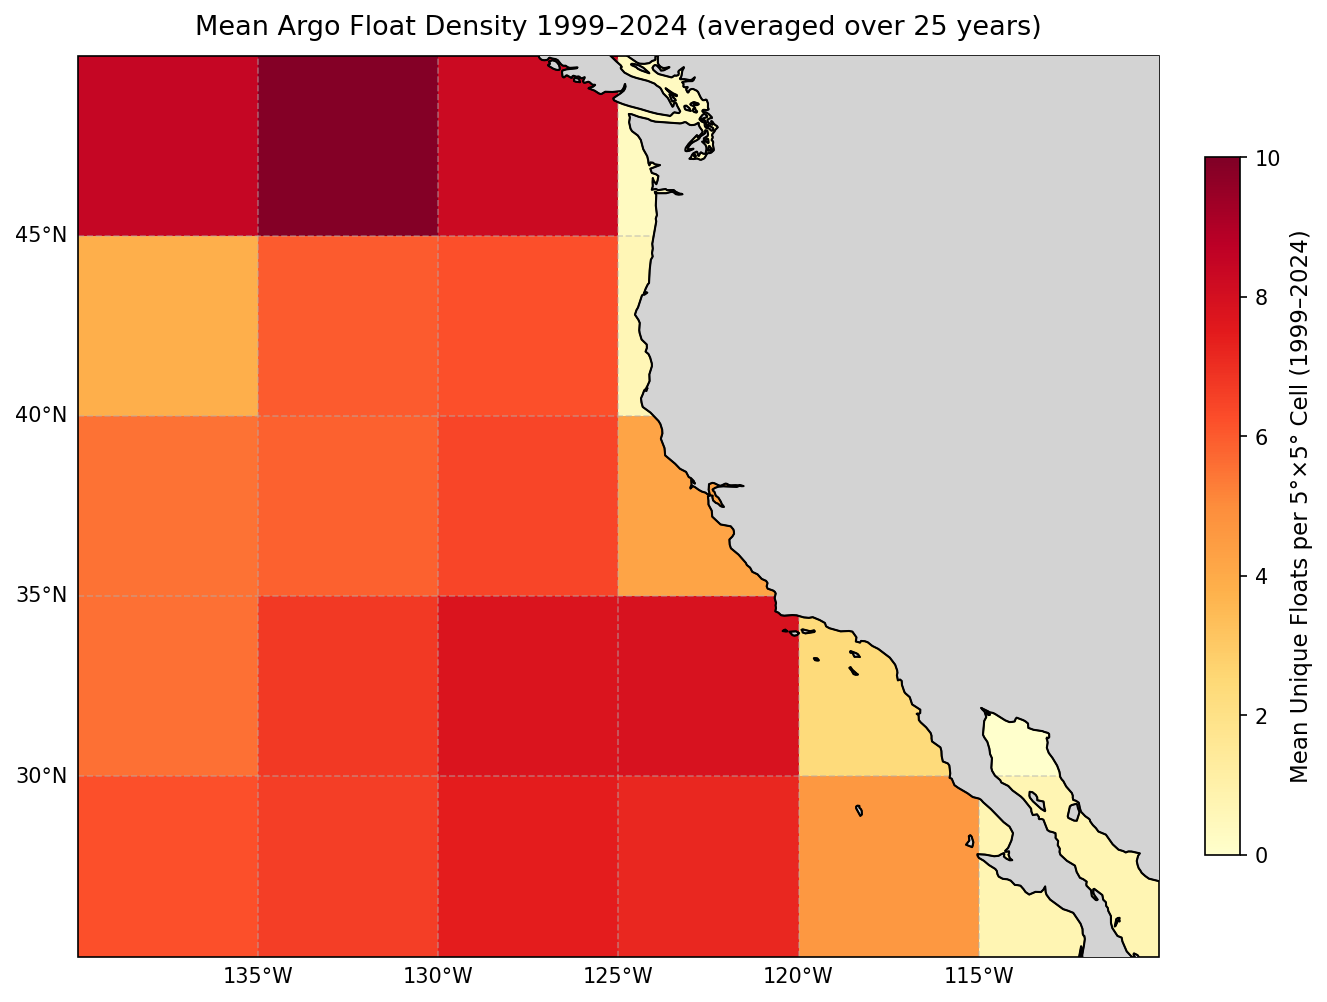

In [4]:
# 26-year mean density map
display(Image(filename=str(CENSUS_DIR / 'float_census_mean_density.png')))

## Per-Year Maps — Interactive Slider

In [ ]:
year_map = {y: p for y, p in zip(years, year_pngs)}

slider = widgets.SelectionSlider(
    options=years,
    value=years[0],
    description='Year:',
    continuous_update=False,
    layout=widgets.Layout(width='600px'),
)

out = widgets.Output()

def show_year(change):
    with out:
        out.clear_output(wait=True)
        display(Image(filename=str(year_map[change['new']])))

slider.observe(show_year, names='value')

# Show initial image
with out:
    display(Image(filename=str(year_map[years[0]])))

display(slider, out)

## All Years — Scroll View

Each year displayed in sequence. Useful for sharing with Gemini or exporting.

In [ ]:
for year, path in zip(years, year_pngs):
    display(Image(filename=str(path)))